# Progetto di Machine Learning: previsione del fabbisogno di riscaldamento degli edifici
## (Energy Efficiency Dataset)

**Metodi utilizzati (argomenti trattati a lezione):**
- **PCA - Analisi delle Componenti Principali** (Cap. 7 - Dimensionality Reduction)
- **Rete Neurale Deep MLP in PyTorch**, con tecniche di addestramento avanzate (Cap. 10-11: Introduction to ANN/PyTorch, Data loaders, Training Deep NN, Learning Rate Scheduling)


## Obiettivo del progetto

Il dataset **Energy Efficiency** (UCI Machine Learning Repository) contiene le caratteristiche
architettoniche di 768 edifici (compattezza, superficie, area dei muri, area del tetto, altezza,
orientamento, area vetrata e sua distribuzione) e due possibili target energetici: il **carico di
riscaldamento** e il **carico di raffreddamento**. In questo progetto ci concentriamo sulla
previsione del **carico di riscaldamento** (task di **regressione**).

A differenza di un semplice confronto tra due modelli indipendenti, qui la **PCA** viene usata come
**fase di pre-processing** della rete neurale: costruiamo una pipeline in cui i dati vengono prima
ridotti di dimensionalità con la PCA, e poi passati alla rete. Per valutare l'effetto reale della
PCA, addestriamo **due versioni della stessa rete** (stessa architettura, stessi iperparametri):
una sui dati originali standardizzati (8 feature) e una sui dati ridotti dalla PCA, confrontando
poi le prestazioni.

## Setup: import delle librerie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# --- Scikit-Learn: split, preprocessing, PCA, metriche ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- PyTorch ---
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

## Analisi esplorativa del dataset (EDA)

In [2]:
# Il file ENB2012_data.csv deve trovarsi nella stessa cartella del notebook.
energy = pd.read_csv("ENB2012_data.csv")

# Rinominiamo le colonne originali (X1..X8, Y1, Y2) con nomi piu' leggibili,
# secondo la documentazione ufficiale del dataset UCI "Energy Efficiency".
energy = energy.rename(columns={
    "X1": "Compattezza_Relativa",
    "X2": "Superficie",
    "X3": "Area_Muri",
    "X4": "Area_Tetto",
    "X5": "Altezza",
    "X6": "Orientamento",
    "X7": "Area_Vetrata",
    "X8": "Distribuzione_Area_Vetrata",
    "Y1": "Carico_Riscaldamento",
    "Y2": "Carico_Raffreddamento"
})

energy.head()

,Compattezza_Relativa,Superficie,Area_Muri,Area_Tetto,Altezza,Orientamento,Area_Vetrata,Distribuzione_Area_Vetrata,Carico_Riscaldamento,Carico_Raffreddamento
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
# info() mostra numero di righe, colonne, tipi di dato e valori non nulli:
# primo controllo da fare su un nuovo dataset, come fatto nel Cap. 2.
energy.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Compattezza_Relativa        768 non-null    float64
 1   Superficie                  768 non-null    float64
 2   Area_Muri                   768 non-null    float64
 3   Area_Tetto                  768 non-null    float64
 4   Altezza                     768 non-null    float64
 5   Orientamento                768 non-null    int64  
 6   Area_Vetrata                768 non-null    float64
 7   Distribuzione_Area_Vetrata  768 non-null    int64  
 8   Carico_Riscaldamento        768 non-null    float64
 9   Carico_Raffreddamento       768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [4]:
# describe() calcola statistiche di base (media, deviazione standard, min, max, quartili)
energy.describe()

,Compattezza_Relativa,Superficie,Area_Muri,Area_Tetto,Altezza,Orientamento,Area_Vetrata,Distribuzione_Area_Vetrata,Carico_Riscaldamento,Carico_Raffreddamento
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [5]:
# Controllo dei valori mancanti
energy.isna().sum()

Compattezza_Relativa          0
Superficie                    0
Area_Muri                     0
Area_Tetto                    0
Altezza                       0
Orientamento                  0
Area_Vetrata                  0
Distribuzione_Area_Vetrata    0
Carico_Riscaldamento          0
Carico_Raffreddamento         0
dtype: int64

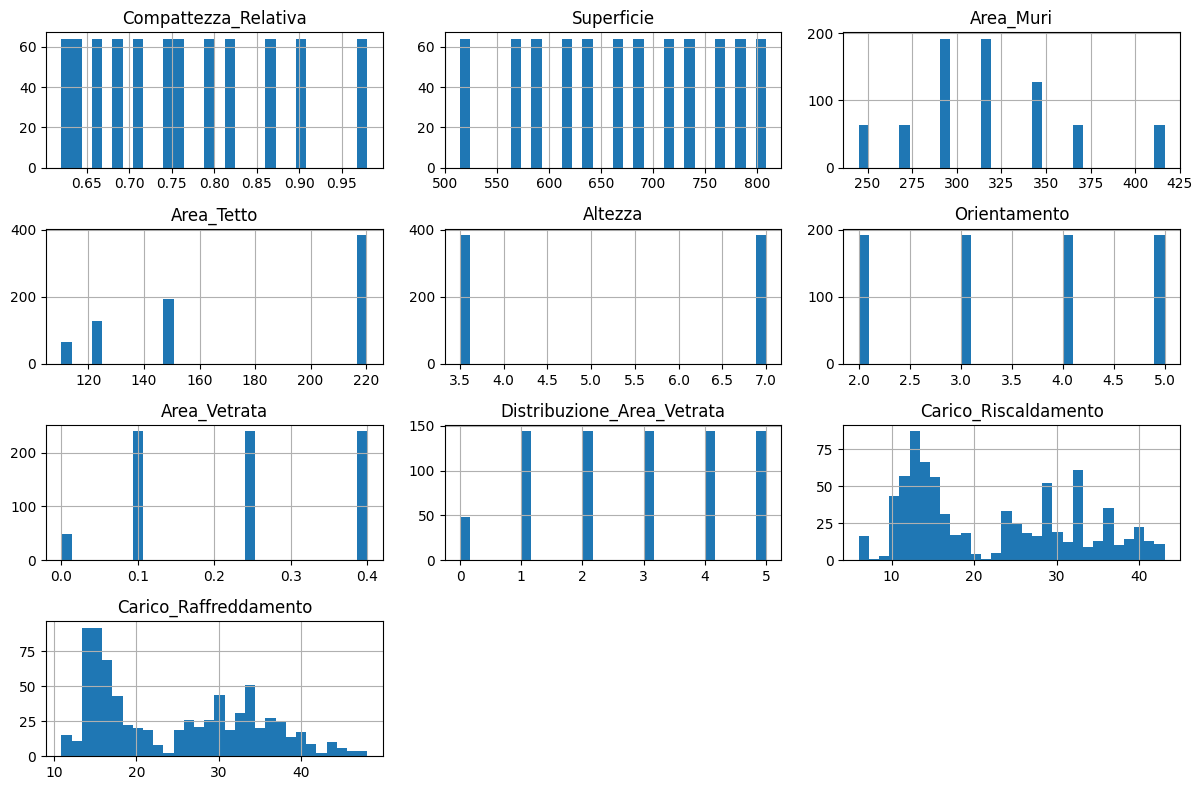

In [6]:
# Istogrammi delle feature numeriche, come fatto nel Cap. 2 per il dataset California Housing.
energy.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

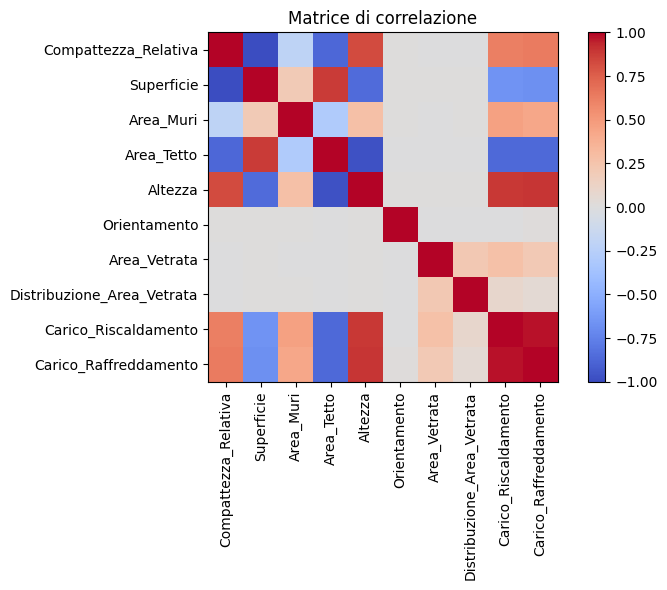

Carico_Riscaldamento          1.000000
Carico_Raffreddamento         0.975862
Altezza                       0.889431
Compattezza_Relativa          0.622272
Area_Muri                     0.455671
Area_Vetrata                  0.269841
Distribuzione_Area_Vetrata    0.087368
Orientamento                 -0.002587
Superficie                   -0.658120
Area_Tetto                   -0.861828
Name: Carico_Riscaldamento, dtype: float64

In [7]:
# Matrice di correlazione tra le feature e il target scelto (Carico_Riscaldamento).
corr = energy.corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matrice di correlazione")
plt.tight_layout()
plt.show()

corr["Carico_Riscaldamento"].sort_values(ascending=False)

Dalla matrice di correlazione si nota che alcune feature (come Compattezza_Relativa, Superficie
e Altezza) sono fortemente correlate con il carico di riscaldamento, ma anche correlate tra loro:
questo rende il dataset un buon candidato per la PCA, che può sfruttare queste ridondanze per
ridurre il numero di dimensioni senza perdere troppa informazione.

## Creazione del training set e del test set

In [8]:
# X contiene le 8 feature predittive, y e' il target (Carico_Riscaldamento).
# L'altro target (Carico_Raffreddamento) viene escluso per evitare data leakage.
X = energy.drop(columns=["Carico_Riscaldamento", "Carico_Raffreddamento"])
y = energy["Carico_Riscaldamento"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (614, 8)
Test set: (154, 8)


## Standardizzazione delle feature

In [9]:
# Sia la PCA sia la rete neurale richiedono feature sulla stessa scala:
# fit dello scaler solo sul training set, poi transform su entrambi.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## PCA - Riduzione della dimensionalità (Cap. 7)

Calcoliamo prima la PCA con tutte le componenti per osservare la varianza spiegata cumulata,
e scegliamo il numero minimo di componenti che conserva almeno il 95% della varianza totale
(criterio spiegato nel Cap. 7).

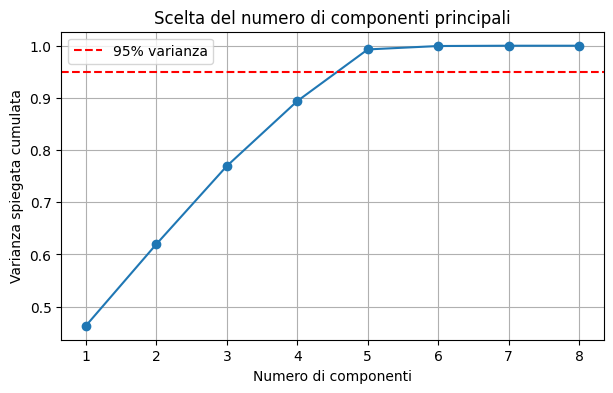

Numero di componenti scelto per il 95% della varianza: 5


In [10]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% varianza")
plt.xlabel("Numero di componenti")
plt.ylabel("Varianza spiegata cumulata")
plt.title("Scelta del numero di componenti principali")
plt.legend()
plt.grid(True)
plt.show()

n_components = np.argmax(cum_var >= 0.95) + 1
print(f"Numero di componenti scelto per il 95% della varianza: {n_components}")

In [11]:
# Applichiamo la PCA con il numero di componenti scelto
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape originale:", X_train_scaled.shape)
print("Shape dopo la PCA:", X_train_pca.shape)

Shape originale: (614, 8)
Shape dopo la PCA: (614, 5)


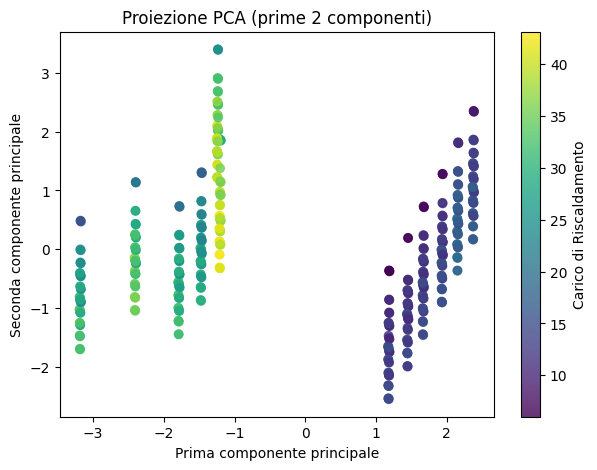

In [12]:
# Visualizzazione delle prime due componenti principali, colorate in base al target:
# permette di vedere se nello spazio ridotto emerge un pattern rispetto al carico di riscaldamento.
plt.figure(figsize=(7, 5))
sc = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="viridis", alpha=0.8)
plt.colorbar(sc, label="Carico di Riscaldamento")
plt.xlabel("Prima componente principale")
plt.ylabel("Seconda componente principale")
plt.title("Proiezione PCA (prime 2 componenti)")
plt.show()

## Preparazione dei dati per PyTorch (Cap. 10)

In [13]:
def make_loaders(X_tr, X_te, y_tr, y_te, batch_size=32):
    """Converte gli array in tensori PyTorch e costruisce i DataLoader
    per il mini-batch gradient descent, come fatto nel Cap. 10."""
    X_tr_t = torch.FloatTensor(np.array(X_tr).copy())
    X_te_t = torch.FloatTensor(np.array(X_te).copy())
    y_tr_t = torch.FloatTensor(np.array(y_tr).copy()).view(-1, 1)
    y_te_t = torch.FloatTensor(np.array(y_te).copy()).view(-1, 1)

    train_ds = TensorDataset(X_tr_t, y_tr_t)
    test_ds = TensorDataset(X_te_t, y_te_t)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, X_te_t, y_te_t

# Due versioni dei dati: originali standardizzati (8 feature) e ridotti dalla PCA
train_loader_orig, test_loader_orig, X_test_t_orig, y_test_t_orig = make_loaders(
    X_train_scaled, X_test_scaled, y_train, y_test)

train_loader_pca, test_loader_pca, X_test_t_pca, y_test_t_pca = make_loaders(
    X_train_pca, X_test_pca, y_train, y_test)

print("Mini-batch per epoca (senza PCA):", len(train_loader_orig))
print("Mini-batch per epoca (con PCA):", len(train_loader_pca))

Mini-batch per epoca (senza PCA): 20
Mini-batch per epoca (con PCA): 20


## Costruzione del modello: Deep MLP (Cap. 10-11)

La rete è una **Deep Neural Network** (più di uno strato nascosto, Cap. 11) con:
- **Inizializzazione He**, indicata nel testo per strati con attivazione ReLU
- **Batch Normalization** dopo ogni strato lineare, per stabilizzare l'addestramento
- **Dropout** per ridurre l'overfitting
- Uscita a singolo neurone senza funzione di attivazione (task di regressione)

Costruiamo una funzione `build_model` in modo da poter creare facilmente due reti identiche
(stessa architettura, stessi iperparametri) che differiscono solo per il numero di feature
in ingresso, così il confronto tra "con PCA" e "senza PCA" è il più equo possibile.

In [14]:
def he_init(module):
    """Inizializzazione He (Kaiming), consigliata per strati seguiti da ReLU (Cap. 11)."""
    if isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
        nn.init.zeros_(module.bias)

def build_model(n_features):
    model = nn.Sequential(
        nn.Linear(n_features, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32, 1)          # uscita singola, nessuna attivazione (regressione)
    )
    model.apply(he_init)
    return model

# Esempio di architettura (8 feature in ingresso)
build_model(8)

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=32, out_features=1, bias=True)
)

## Funzioni di addestramento e valutazione

- **Loss**: `MSELoss`, la scelta standard per la regressione
- **Ottimizzatore**: **Adam** (Cap. 11)
- **Learning Rate Scheduling**: `ExponentialLR`, come descritto nella sezione "Exponential
  Scheduling" del Cap. 11, per ridurre gradualmente il learning rate durante l'addestramento

In [15]:
def train_model(model, train_loader, n_epochs=100, lr=0.01):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.97)

    history = []
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

        scheduler.step()
        epoch_loss = total_loss / len(train_loader.dataset)
        history.append(epoch_loss)

    return history

def evaluate_model(model, X_test_t, y_test_t):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).numpy().ravel()
    y_true = y_test_t.numpy().ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2, y_pred

## Addestramento del modello senza PCA (8 feature originali)

In [16]:
torch.manual_seed(RANDOM_STATE)
model_orig = build_model(X_train_scaled.shape[1])

t0 = time.time()
history_orig = train_model(model_orig, train_loader_orig, n_epochs=100, lr=0.01)
time_orig = time.time() - t0

rmse_orig, mae_orig, r2_orig, y_pred_orig = evaluate_model(model_orig, X_test_t_orig, y_test_t_orig)

print(f"RMSE: {rmse_orig:.4f} | MAE: {mae_orig:.4f} | R2: {r2_orig:.4f} | Tempo: {time_orig:.2f}s")

RMSE: 2.2520 | MAE: 1.7765 | R2: 0.9513 | Tempo: 5.68s


## Addestramento del modello con PCA

In [17]:
torch.manual_seed(RANDOM_STATE)
model_pca = build_model(X_train_pca.shape[1])

t0 = time.time()
history_pca = train_model(model_pca, train_loader_pca, n_epochs=100, lr=0.01)
time_pca = time.time() - t0

rmse_pca, mae_pca, r2_pca, y_pred_pca = evaluate_model(model_pca, X_test_t_pca, y_test_t_pca)

print(f"RMSE: {rmse_pca:.4f} | MAE: {mae_pca:.4f} | R2: {r2_pca:.4f} | Tempo: {time_pca:.2f}s")

RMSE: 2.5798 | MAE: 1.9218 | R2: 0.9361 | Tempo: 4.23s


## Curve di apprendimento (Cap. 4)

Confrontiamo l'andamento della loss durante l'addestramento per le due versioni della rete,
per valutare se convergono in modo simile.

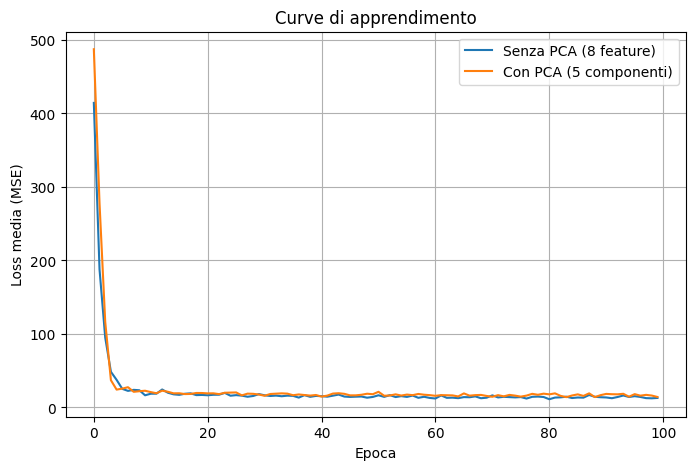

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history_orig, label="Senza PCA (8 feature)")
plt.plot(history_pca, label=f"Con PCA ({n_components} componenti)")
plt.xlabel("Epoca")
plt.ylabel("Loss media (MSE)")
plt.title("Curve di apprendimento")
plt.legend()
plt.grid(True)
plt.show()

## Confronto finale: MLP senza PCA vs MLP con PCA

In [19]:
results = pd.DataFrame({
    "Modello": ["MLP senza PCA (8 feature)", f"MLP con PCA ({n_components} componenti)"],
    "RMSE": [rmse_orig, rmse_pca],
    "MAE": [mae_orig, mae_pca],
    "R2": [r2_orig, r2_pca],
    "Tempo addestramento (s)": [time_orig, time_pca],
})
results.round(4)

,Modello,RMSE,MAE,R2,Tempo addestramento (s)
0,MLP senza PCA (8 feature),2.2520,1.7765,0.9513,5.6759
1,MLP con PCA (5 componenti),2.5798,1.9218,0.9361,4.2255


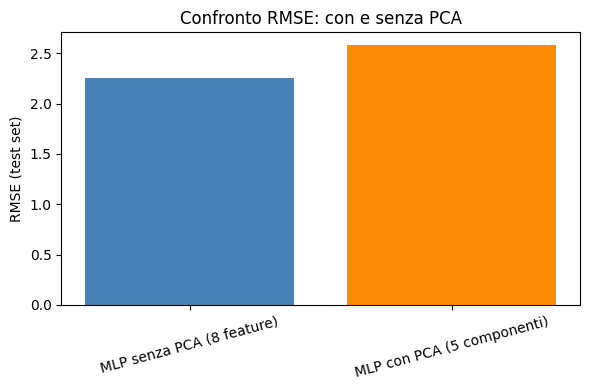

In [20]:
plt.figure(figsize=(6, 4))
plt.bar(results["Modello"], results["RMSE"], color=["steelblue", "darkorange"])
plt.ylabel("RMSE (test set)")
plt.title("Confronto RMSE: con e senza PCA")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

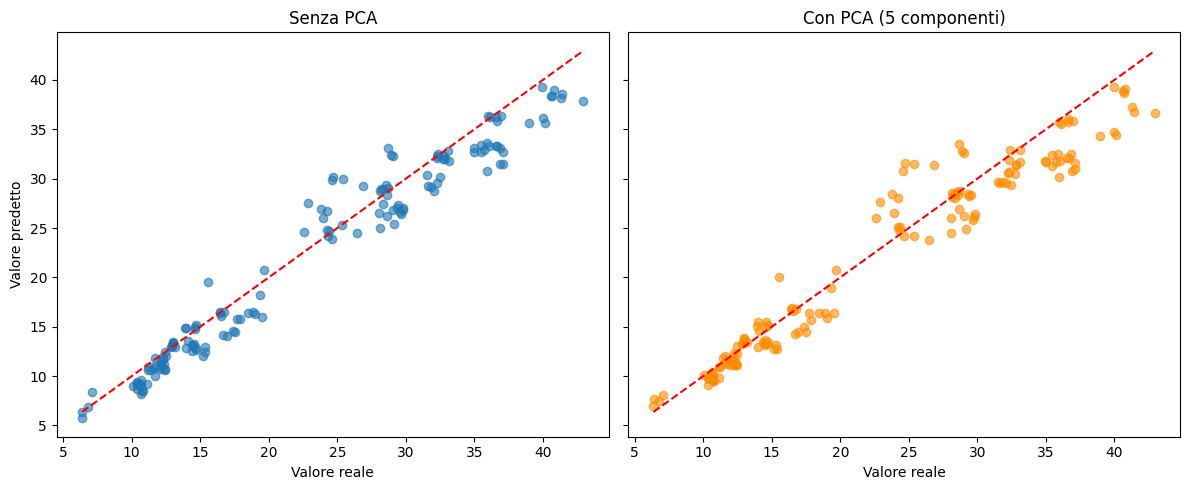

In [21]:
# Confronto grafico tra valori reali e valori predetti, per entrambi i modelli
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].scatter(y_test, y_pred_orig, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title("Senza PCA")
axes[0].set_xlabel("Valore reale")
axes[0].set_ylabel("Valore predetto")

axes[1].scatter(y_test, y_pred_pca, alpha=0.6, color="darkorange")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_title(f"Con PCA ({n_components} componenti)")
axes[1].set_xlabel("Valore reale")

plt.tight_layout()
plt.show()

## Conclusioni

Entrambe le versioni della rete neurale ottengono un R² elevato, a conferma che il problema è
ben risolvibile con un MLP allenato secondo le tecniche del Cap. 11 (inizializzazione He, Batch
Normalization, Dropout, Adam, Learning Rate Scheduling).

Confrontando i due approcci:

- Il modello **senza PCA** (8 feature originali) ottiene un RMSE leggermente più basso: avendo
  a disposizione tutta l'informazione originale, riesce a modellare meglio le relazioni tra le
  variabili architettoniche e il carico di riscaldamento.
- Il modello **con PCA** riduce il numero di feature in ingresso (da 8 a poche componenti che
  spiegano il 95% della varianza), pagando una piccola perdita di accuratezza ma con un
  **tempo di addestramento inferiore**, grazie alla dimensionalità ridotta.

Questo risultato è coerente con quanto discusso nel Cap. 7: la PCA è utile quando si vuole
ridurre la complessità computazionale o visualizzare i dati, ma può comportare una perdita di
informazione se il numero originale di feature non è molto elevato, come nel caso di questo
dataset con sole 8 variabili. In problemi con molte più feature (centinaia o migliaia), il
vantaggio della PCA in termini di efficienza tenderebbe a farsi più marcato.